In [92]:
import pandas as pd
import matplotlib.pyplot as plt

# load historian data
df = pd.read_csv(r"..\data\processed\swat_cleaned.csv")
df.head()

,t_stamp,P1_STATE,LIT101.Pv,FIT101.Pv,MV101.Status,P101.Status,P102.Status,P2_STATE,FIT201.Pv,AIT201.Pv,...,FIT601.Pv,P601.Status,P602.Status,P603.Status,LSH601.Alarm,LSL601.Alarm,LSH602.Alarm,LSL602.Alarm,LSH603.Alarm,LSL603.Alarm
0,2019-12-06 10:05:00,3,658.661255,0.0,1,2.0,1,2,2.313523,35.21533,...,0.000256,2,1,1,0,0,1,0,0,1
1,2019-12-06 10:05:01,3,659.171600,0.0,1,2.0,1,2,2.311857,35.21533,...,0.000256,2,1,1,0,0,1,0,0,1
2,2019-12-06 10:05:02,3,659.681800,0.0,1,2.0,1,2,2.311601,35.21533,...,0.000256,2,1,1,0,0,1,0,0,1
3,2019-12-06 10:05:03,3,660.349100,0.0,1,2.0,1,2,2.310448,35.21533,...,0.000256,2,1,1,0,0,1,0,0,1
4,2019-12-06 10:05:04,3,660.780945,0.0,1,2.0,1,2,2.310448,35.21533,...,0.000256,2,1,1,0,0,1,0,0,1


In [93]:
print(df.columns)

Index(['t_stamp', 'P1_STATE', 'LIT101.Pv', 'FIT101.Pv', 'MV101.Status',
       'P101.Status', 'P102.Status', 'P2_STATE', 'FIT201.Pv', 'AIT201.Pv',
       'AIT202.Pv', 'AIT203.Pv', 'MV201.Status', 'P201.Status', 'P202.Status',
       'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status',
       'P207.Status', 'P208.Status', 'LS201.Alarm', 'LS202.Alarm',
       'LSL203.Alarm', 'LSLL203.Alarm', 'P3_STATE', 'AIT301.Pv', 'AIT302.Pv',
       'AIT303.Pv', 'LIT301.Pv', 'FIT301.Pv', 'DPIT301.Pv', 'MV301.Status',
       'MV302.Status', 'MV303.Status', 'MV304.Status', 'P301.Status',
       'P302.Status', 'PSH301.Alarm', 'DPSH301.Alarm', 'P4_STATE', 'LIT401.Pv',
       'FIT401.Pv', 'AIT401.Pv', 'AIT402.Pv', 'P401.Status', 'P402.Status',
       'P403.Status', 'P404.Status', 'UV401.Status', 'LS401.Alarm', 'P5_STATE',
       'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'AIT501.Pv',
       'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'PIT501.Pv', 'PIT502.Pv',
       'PIT503.Pv', 'P501.Status', '

In [94]:
df['t_stamp'] = pd.to_datetime(df['t_stamp'])

df = df.sort_values('t_stamp').reset_index(drop=True)
df = df.set_index('t_stamp')
print(df.index.min())
print(df.index.max())

2019-12-06 10:05:00
2019-12-06 13:45:00


In [95]:
time_diffs = df.index.to_series().diff().dropna()
print(time_diffs.value_counts().head())

t_stamp
0 days 00:00:01    13200
Name: count, dtype: int64


In [21]:
NORMAL_END = pd.Timestamp("2019-12-06 10:20:00")

CYBER_ATTACK_START = pd.Timestamp("2019-12-06 10:30:00")
CYBER_ATTACK_END   = pd.Timestamp("2019-12-06 11:20:00")

PHYSICAL_ATTACK_START = pd.Timestamp("2019-12-06 12:30:00")
PHYSICAL_ATTACK_END   = pd.Timestamp("2019-12-06 13:25:00")

POST_ATTACK_START = pd.Timestamp("2019-12-06 13:30:00")


In [97]:
mask_normal = df.index < NORMAL_END

mask_cyber_attack = (
    (df.index >= CYBER_ATTACK_START) &
    (df.index <= CYBER_ATTACK_END)
)

mask_physical_attack = (
    (df.index >= PHYSICAL_ATTACK_START) &
    (df.index <= PHYSICAL_ATTACK_END)
)

mask_post_attack = df.index >= POST_ATTACK_START

print("Normal:", mask_normal.sum())
print("Cyber attack:", mask_cyber_attack.sum())
print("Physical attack:", mask_physical_attack.sum())
print("Post attack:", mask_post_attack.sum())


Normal: 900
Cyber attack: 3001
Physical attack: 3301
Post attack: 901


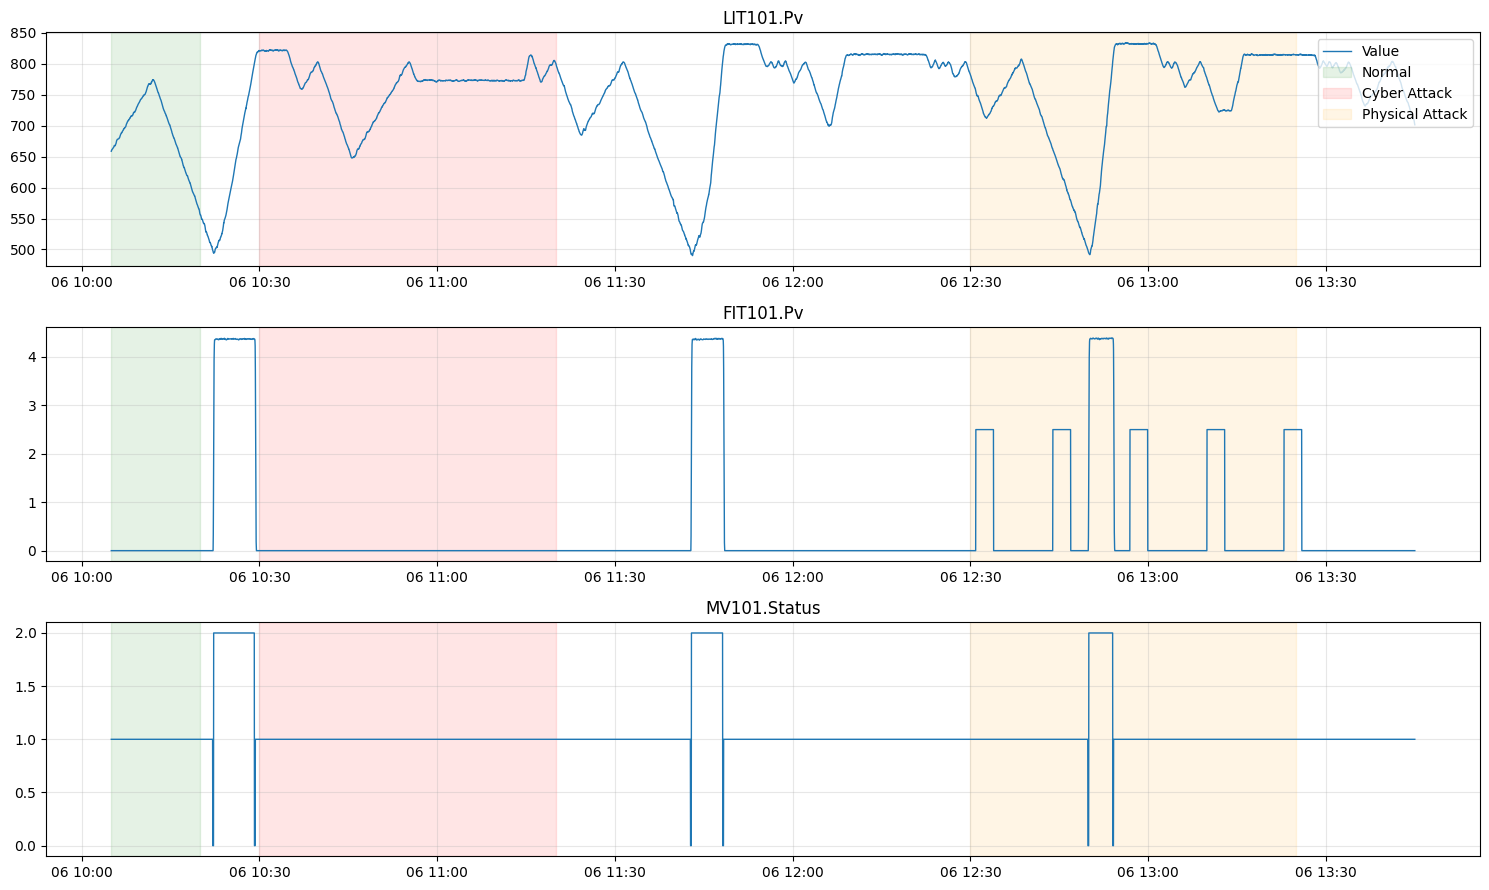

In [98]:
import matplotlib.pyplot as plt

# Select a few 'Pv' (Process value) and 'Status' columns to plot sample data
plot_cols = [c for c in df.columns if 'Pv' in c][:2] + [c for c in df.columns if 'Status' in c][:1]

if not plot_cols:
    plot_cols = df.columns[:3]

plt.figure(figsize=(15, 3 * len(plot_cols)))

for i, col in enumerate(plot_cols):
    plt.subplot(len(plot_cols), 1, i+1)
    plt.plot(df.index, df[col], label='Value', linewidth=1, color='tab:blue')
    
    # Shade the different phases
    plt.axvspan(df.index.min(), NORMAL_END, color='green', alpha=0.1, label='Normal' if i==0 else None)
    plt.axvspan(CYBER_ATTACK_START, CYBER_ATTACK_END, color='red', alpha=0.1, label='Cyber Attack' if i==0 else None)
    plt.axvspan(PHYSICAL_ATTACK_START, PHYSICAL_ATTACK_END, color='orange', alpha=0.1, label='Physical Attack' if i==0 else None)
    
    plt.title(col)
    plt.grid(True, alpha=0.3)
    if i == 0:
        plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [99]:
df_clean = df.copy()

cols = df_clean.columns.tolist()
print(cols)

['P1_STATE', 'LIT101.Pv', 'FIT101.Pv', 'MV101.Status', 'P101.Status', 'P102.Status', 'P2_STATE', 'FIT201.Pv', 'AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'MV201.Status', 'P201.Status', 'P202.Status', 'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status', 'P207.Status', 'P208.Status', 'LS201.Alarm', 'LS202.Alarm', 'LSL203.Alarm', 'LSLL203.Alarm', 'P3_STATE', 'AIT301.Pv', 'AIT302.Pv', 'AIT303.Pv', 'LIT301.Pv', 'FIT301.Pv', 'DPIT301.Pv', 'MV301.Status', 'MV302.Status', 'MV303.Status', 'MV304.Status', 'P301.Status', 'P302.Status', 'PSH301.Alarm', 'DPSH301.Alarm', 'P4_STATE', 'LIT401.Pv', 'FIT401.Pv', 'AIT401.Pv', 'AIT402.Pv', 'P401.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'UV401.Status', 'LS401.Alarm', 'P5_STATE', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv', 'P501.Status', 'P502.Status', 'MV501.Status', 'MV502.Status', 'MV503.Status', 'MV504.Status', 'PSH501.Alarm', 'PSL501.Alarm'

In [100]:
import re

def classify_type(col):
    if col.endswith('.Pv'):
        return 'Pv'
    elif col.endswith('.Status'):
        return 'Status'
    elif col.endswith('.Alarm'):
        return 'Alarm'
    elif re.match(r'^P[1-6]_STATE$', col):
        return 'State'
    else:
        return 'Other'


def extract_stage(col):
    # P*_STATE
    m = re.match(r'^P([1-6])_STATE$', col)
    if m:
        return f'P{m.group(1)}'
    
    # Tags like LIT101, MV301, FIT601, etc.
    m = re.search(r'(\d{3})', col)
    if m:
        block = int(m.group(1))
        if 100 <= block < 200:
            return 'P1'
        elif 200 <= block < 300:
            return 'P2'
        elif 300 <= block < 400:
            return 'P3'
        elif 400 <= block < 500:
            return 'P4'
        elif 500 <= block < 600:
            return 'P5'
        elif 600 <= block < 700:
            return 'P6'
    return 'Unknown'


In [101]:
meta = []

for col in cols:
    meta.append({
        'column': col,
        'type': classify_type(col),
        'stage': extract_stage(col)
    })

meta_df = pd.DataFrame(meta)
print(meta_df.head(10))

         column    type stage
0      P1_STATE   State    P1
1     LIT101.Pv      Pv    P1
2     FIT101.Pv      Pv    P1
3  MV101.Status  Status    P1
4   P101.Status  Status    P1
5   P102.Status  Status    P1
6      P2_STATE   State    P2
7     FIT201.Pv      Pv    P2
8     AIT201.Pv      Pv    P2
9     AIT202.Pv      Pv    P2


In [102]:
print(meta_df['type'].value_counts())
print(meta_df['stage'].value_counts())

meta_df.to_csv("../data/processed/step2/swat_feature_metadata.csv", index=False)

type
Status    32
Pv        28
Alarm     15
State      6
Name: count, dtype: int64
stage
P5    20
P2    18
P3    15
P4    11
P6    11
P1     6
Name: count, dtype: int64


In [103]:
meta_df = pd.read_csv("../data/processed/step2/swat_feature_metadata.csv")

alarm_cols = meta_df.loc[meta_df['type'] == 'Alarm', 'column'].tolist()

df_step3 = df_clean.drop(columns=alarm_cols)

print("Dropped Alarm columns:", len(alarm_cols))

Dropped Alarm columns: 15


In [104]:
pv_cols = meta_df.loc[meta_df['type'] == 'Pv', 'column']
pv_cols = [c for c in pv_cols if c in df_step3.columns]

df_step3[pv_cols] = df_step3[pv_cols].astype(float)
print("Converted Pv columns to float:", len(pv_cols))

Converted Pv columns to float: 28


In [105]:
status_cols = meta_df.loc[meta_df['type'] == 'Status', 'column']
status_cols = [c for c in status_cols if c in df_step3.columns]

# Use 'Int64' (capital I) to handle NaN values
df_step3[status_cols] = df_step3[status_cols].astype('Int64')
print("Converted Status columns to int:", len(status_cols))

Converted Status columns to int: 32


In [106]:
state_cols = meta_df.loc[meta_df['type'] == 'State', 'column']
state_cols = [c for c in state_cols if c in df_step3.columns]

df_step3[state_cols] = df_step3[state_cols].astype(int)
print("Converted State columns to int:", len(state_cols))

Converted State columns to int: 6


In [107]:
df_step3.dtypes.value_counts()

Int64      32
float64    28
int64       6
Name: count, dtype: int64

In [108]:
df_step3.to_csv("../data/processed/step3/swat_step3_clean.csv")

In [109]:
import pandas as pd
import numpy as np

# When loading the CSV back, the index is lost (it becomes a regular column or range index)
# We need to set the index back to datetime!
df_step3 = pd.read_csv("../data/processed/step3/swat_step3_clean.csv")

# Convert t_stamp to datetime again
if 't_stamp' in df_step3.columns:
    df_step3['t_stamp'] = pd.to_datetime(df_step3['t_stamp'])
    df_step3 = df_step3.set_index('t_stamp')

meta_df = pd.read_csv("../data/processed/step2/swat_feature_metadata.csv")

pv_cols = meta_df.loc[meta_df['type'] == 'Pv', 'column']
pv_cols = [c for c in pv_cols if c in df_step3.columns]
print(pv_cols[:5])

['LIT101.Pv', 'FIT101.Pv', 'FIT201.Pv', 'AIT201.Pv', 'AIT202.Pv']


In [110]:
# Check for missing values
print("Missing values before imputation:", df_step3.isna().sum().sum())

# Impute missing values using forward fill (propagate last valid observation)
# and backward fill (for any initial missing values)
df_step3 = df_step3.ffill().bfill()

print("Missing values after imputation:", df_step3.isna().sum().sum())

Missing values before imputation: 1
Missing values after imputation: 0


In [111]:
NORMAL_END = pd.Timestamp("2019-12-06 10:20:00")

df_train_norm = df_step3.loc[df_step3.index < NORMAL_END]
print("Training data shape:", df_train_norm.shape)

print(df_train_norm.index.min(), df_train_norm.index.max())


Training data shape: (900, 66)
2019-12-06 10:05:00 2019-12-06 10:19:59


In [112]:
pv_mean = df_train_norm[pv_cols].mean()
pv_std  = df_train_norm[pv_cols].std()

# Replace 0.0 standard deviations with 1.0 to avoid division by zero
# These are constant columns, so they will become 0 after normalization
pv_std = pv_std.replace(0.0, 1.0)

df_step4 = df_step3.copy()
print("Before normalization:")
print(df_step4[pv_cols].iloc[0:5])
df_step4[pv_cols] = (df_step4[pv_cols] - pv_mean) / pv_std

print("After normalization:")
print(df_step4[pv_cols].iloc[0:5])

Before normalization:
                      LIT101.Pv  FIT101.Pv  FIT201.Pv  AIT201.Pv  AIT202.Pv  \
t_stamp                                                                       
2019-12-06 10:05:00  658.661255        0.0   2.313523   35.21533   8.205781   
2019-12-06 10:05:01  659.171600        0.0   2.311857   35.21533   8.205781   
2019-12-06 10:05:02  659.681800        0.0   2.311601   35.21533   8.208344   
2019-12-06 10:05:03  660.349100        0.0   2.310448   35.21533   8.209626   
2019-12-06 10:05:04  660.780945        0.0   2.310448   35.21533   8.209626   

                      AIT203.Pv  AIT301.Pv   AIT302.Pv  AIT303.Pv   LIT301.Pv  \
t_stamp                                                                         
2019-12-06 10:05:00  133.350418   6.792944  155.579742  35.149494  895.123047   
2019-12-06 10:05:01  133.401688   6.793777  155.579742  35.245533  895.123047   
2019-12-06 10:05:02  133.606766   6.795025  155.579742  35.245533  895.123047   
2019-12-06 10:05:03

In [113]:
df_step4.loc[df_step4.index < NORMAL_END, pv_cols].describe().loc[['mean', 'std']]

,LIT101.Pv,FIT101.Pv,FIT201.Pv,AIT201.Pv,AIT202.Pv,AIT203.Pv,AIT301.Pv,AIT302.Pv,AIT303.Pv,LIT301.Pv,...,FIT503.Pv,FIT504.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,PIT501.Pv,PIT502.Pv,PIT503.Pv,FIT601.Pv
mean,3.852721e-15,0.0,-3.676269e-13,2.545322e-14,3.277970e-14,-1.652249e-13,-1.362979e-13,5.671710e-14,-2.305316e-13,-6.505413e-15,...,9.430836e-13,0.0,3.606399e-13,8.691990e-13,-2.899646e-13,-4.692740e-14,-3.541282e-12,1.061709e-12,-1.738651e-12,0.999444
std,1.000000e+00,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,0.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000


In [114]:
scaler = {
    'mean': pv_mean,
    'std': pv_std
}

pd.to_pickle(scaler, "../data/processed/step4/swat_pv_scaler.pkl")

In [115]:
df_step4.to_csv("../data/processed/step4/swat_step4_normalized.csv")

In [116]:
######################################

In [117]:
df = pd.read_csv("../data/processed/step4/swat_step4_normalized.csv")

if 't_stamp' in df.columns:
    df['t_stamp'] = pd.to_datetime(df['t_stamp'])
    df = df.set_index('t_stamp')

meta_df = pd.read_csv("../data/processed/step2/swat_feature_metadata.csv")

WINDOW_SIZE = 60      # seconds
STRIDE = 1            # seconds

In [118]:
def create_sliding_windows(df, window_size, stride):
    X = []
    window_start_times = []
    window_end_times = []

    values = df.values
    index = df.index

    for start in range(0, len(df) - window_size + 1, stride):
        end = start + window_size

        # Check for continuous timestamps (1-second sampling)
        expected_duration = pd.Timedelta(seconds=window_size - 1)
        if index[end - 1] - index[start] != expected_duration:
            continue

        X.append(values[start:end])
        window_start_times.append(index[start])
        window_end_times.append(index[end - 1])

    X = np.stack(X)
    return X, window_start_times, window_end_times


In [119]:
X_all, win_start, win_end = create_sliding_windows(
    df,
    WINDOW_SIZE,
    STRIDE
)

print("Windowed tensor shape:", X_all.shape)


Windowed tensor shape: (13142, 60, 66)


In [120]:
win_start = np.array(win_start)
win_end = np.array(win_end)


In [121]:
NORMAL_END = pd.Timestamp("2019-12-06 10:20:00")
CYBER_ATTACK_START = pd.Timestamp("2019-12-06 10:30:00")
CYBER_ATTACK_END   = pd.Timestamp("2019-12-06 11:20:00")
PHYSICAL_ATTACK_START = pd.Timestamp("2019-12-06 12:30:00")
PHYSICAL_ATTACK_END   = pd.Timestamp("2019-12-06 13:25:00")

window_phase = np.full(len(win_start), "neutral", dtype=object)

window_phase[win_end < NORMAL_END] = "normal"

window_phase[
    (win_start <= CYBER_ATTACK_END) &
    (win_end >= CYBER_ATTACK_START)
] = "cyber_attack"

window_phase[
    (win_start <= PHYSICAL_ATTACK_END) &
    (win_end >= PHYSICAL_ATTACK_START)
] = "physical_attack"


print(pd.Series(window_phase).value_counts())

neutral            5881
physical_attack    3360
cyber_attack       3060
normal              841
Name: count, dtype: int64


In [122]:
# Let's inspect the "neutral" phases to understand what they are
neutral_mask = (window_phase == "neutral")
neutral_starts = win_start[neutral_mask]
neutral_ends = win_end[neutral_mask]

if len(neutral_starts) > 0:
    print(f"Number of neutral windows: {len(neutral_starts)}")
    print("Sample neutral window starts:")
    print(pd.to_datetime(neutral_starts[:5]))
    
    # Check if they align with the gaps we identified earlier
    # Gap 1: 10:20 - 10:30 (Between Normal and Cyber)
    # Gap 2: 11:20 - 12:30 (Between Cyber and Physical)
    # Gap 3: 13:25 - End (Post Attack)
    
    # Let's see unique dates to confirm
    print("\nUnique dates in neutral windows:")
    print(np.unique(pd.to_datetime(neutral_starts).date))
else:
    print("No neutral windows found.")

Number of neutral windows: 5881
Sample neutral window starts:
DatetimeIndex(['2019-12-06 10:19:01', '2019-12-06 10:19:02',
               '2019-12-06 10:19:03', '2019-12-06 10:19:04',
               '2019-12-06 10:19:05'],
              dtype='datetime64[ns]', freq=None)

Unique dates in neutral windows:
[datetime.date(2019, 12, 6)]


In [123]:
X_train = X_all[window_phase == "normal"]
print("Training windows:", X_train.shape[0])


Training windows: 841


In [124]:
np.save("../data/processed/step5/X_all_windows.npy", X_all)
np.save("../data/processed/step5/window_phase.npy", window_phase)
np.save("../data/processed/step5/window_start_times.npy", win_start)
np.save("../data/processed/step5/window_end_times.npy", win_end)
np.save("../data/processed/step5/X_train_windows.npy", X_train)

In [157]:
import numpy as np
import pandas as pd


In [158]:
X_all = np.load("../data/processed/step5/X_all_windows.npy")
X_train = np.load("../data/processed/step5/X_train_windows.npy")

win_start = np.load("../data/processed/step5/window_start_times.npy", allow_pickle=True)
win_end   = np.load("../data/processed/step5/window_end_times.npy", allow_pickle=True)
meta_df = pd.read_csv("../data/processed/step2/swat_feature_metadata.csv")

df_step4 = pd.read_csv("../data/processed/step4/swat_step4_normalized.csv")
feature_columns = df_step4.columns.tolist()

# fix time series index if needed
if 't_stamp' in df_step4.columns:
    df_step4['t_stamp'] = pd.to_datetime(df_step4['t_stamp'])
    df_step4 = df_step4.set_index('t_stamp')

In [159]:
# feature_columns MUST exclude t_stamp
feature_columns = [c for c in df_step4.columns if c != 't_stamp']

col_to_idx = {col: i for i, col in enumerate(feature_columns)}

# sanity check
assert X_all.shape[2] == len(feature_columns)


In [160]:
stage_features = {}

for stage in ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']:
    cols = meta_df.loc[
        (meta_df['stage'] == stage) &
        (meta_df['type'].isin(['Pv', 'Status', 'State'])),
        'column'
    ].tolist()

    # keep only valid feature columns
    cols = [c for c in cols if c in col_to_idx]

    stage_features[stage] = cols

stage_feature_indices = {
    stage: [col_to_idx[c] for c in cols]
    for stage, cols in stage_features.items()
}

In [161]:
X_all_stage = {}
X_train_stage = {}

for stage, idxs in stage_feature_indices.items():
    X_all_stage[stage] = X_all[:, :, idxs]
    X_train_stage[stage] = X_train[:, :, idxs]

for stage in X_all_stage:
    print(
        stage,
        X_all_stage[stage].shape,
        X_train_stage[stage].shape
    )


P1 (13142, 60, 6) (841, 60, 6)
P2 (13142, 60, 14) (841, 60, 14)
P3 (13142, 60, 13) (841, 60, 13)
P4 (13142, 60, 10) (841, 60, 10)
P5 (13142, 60, 18) (841, 60, 18)
P6 (13142, 60, 5) (841, 60, 5)


In [162]:
for stage in X_all_stage:
    np.save(f"../data/processed/step6/X_all_{stage}.npy", X_all_stage[stage])
    np.save(f"../data/processed/step6/X_train_{stage}.npy", X_train_stage[stage])


import json

with open("../data/processed/step6/stage_feature_map.json", "w") as f:
    json.dump(stage_features, f, indent=2)

#### TRAINING

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [7]:
class WindowDataset(Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


In [8]:
X_train = np.load("../data/processed/step6/X_train_P1.npy")

train_dataset = WindowDataset(X_train)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    drop_last=True
)

In [9]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = 2
        
        # Encoder
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=0.1  # Reduced dropout
        )
        
        # Latent Projection
        self.hidden2latent = nn.Linear(hidden_dim, latent_dim)
        self.latent2hidden = nn.Linear(latent_dim, hidden_dim)
        
        # Decoder
        self.decoder = nn.LSTM(
            input_size=latent_dim, 
            hidden_size=hidden_dim,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=0.1
        )
        
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        
        # --- Encode ---
        _, (h_n, c_n) = self.encoder(x)
        
        # We process the hidden state of the LAST layer for the bottleneck
        # h_n shape: (num_layers, B, hidden)
        last_hidden = h_n[-1] # (B, hidden)
        
        # Compression
        latent = self.hidden2latent(last_hidden) # (B, latent)
        
        # Expand latent to sequence for Decoder Input
        # (B, latent) -> (B, seq_len, latent)
        latent_seq = latent.unsqueeze(1).repeat(1, seq_len, 1)
        
        # --- Decode ---
        # Initialize decoder state with the projected latent vector
        # We assume c_0 is 0, or we could learn to project specific c_0
        # To strictly use the bottleneck, we reconstruct the initial hidden state from the latent
        
        init_hidden = self.latent2hidden(latent) # (B, hidden)
        
        # Create a hidden state stack for all layers
        # (num_layers, B, hidden)
        h_0_dec = init_hidden.unsqueeze(0).repeat(self.num_layers, 1, 1)
        c_0_dec = torch.zeros_like(h_0_dec) 
        
        # Pass the latent sequence as input, AND the initialized states
        dec_out, _ = self.decoder(latent_seq, (h_0_dec, c_0_dec))
        
        # Map to original dimension
        x_hat = self.output_layer(dec_out)
        
        return x_hat

In [10]:
# DEBUG: Check X_train statistics to ensure it's not washed out
print("X_train shape:", X_train.shape)
print("X_train mean:", np.mean(X_train))
print("X_train std:", np.std(X_train))
print("Sample window (first feature):\n", X_train[0, :10, 0])

# Ensure there's variation
if np.std(X_train) < 0.1:
    print("\nWARNING: Low overall variance. Check normalization.")
else:
    print("\nVariance looks okay.")

X_train shape: (841, 60, 6)
X_train mean: 1.1821119826763389
X_train std: 1.1188921984190359
Sample window (first feature):
 [3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]

Variance looks okay.


In [15]:
# DEBUG NA SOURCE
import json
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Identify which features have NaN
nan_indices = np.where(np.isnan(X_train).any(axis=(0, 1)))[0]
print(f"Indices of features with NaN: {nan_indices}")

# 2. Try to map back to column names
try:
    with open("../data/processed/step6/stage_feature_map.json", "r") as f:
        stage_map = json.load(f)
    
    # We are training on P1, so look at P1 columns
    p1_cols = stage_map.get('P1', [])
    
    if len(p1_cols) == X_train.shape[2]:
        print("\nFeatures containing NaNs:")
        for idx in nan_indices:
            print(f"  {idx}: {p1_cols[idx]}")
    else:
        print("\nWarning: Number of P1 columns in map doesn't match entries in X_train.")
        print(f"Map: {len(p1_cols)}, X_train: {X_train.shape[2]}")

except Exception as e:
    print(f"Could not load feature map: {e}")

# 3. Check if these are potentially 'Zero Variance' columns (std=0) which cause NaN during normalization
# We can check the scaler if available, or just infer.
try:
    scaler = pd.read_pickle("../data/processed/step4/swat_pv_scaler.pkl")
    stds = scaler['std']
    
    print("\nChecking Standard Deviations for these columns:")
    for idx in nan_indices:
        col_name = p1_cols[idx] if idx < len(p1_cols) else None
        if col_name and col_name in stds:
             print(f"  {col_name} std: {stds[col_name]}")
        else:
             print(f"  Index {idx}: Std not found in scaler")

except Exception as e:
    print(f"Could not check scaler: {e}")

Indices of features with NaN: []

Features containing NaNs:

Checking Standard Deviations for these columns:


In [16]:
import os

# Create directory if it doesn't exist
os.makedirs("../models/lstm", exist_ok=True)

EPOCHS = 150
patience = 10
patience_counter = 0
best_loss = float("inf")

print(f"Starting training on {device} (Max Epochs: {EPOCHS}, Patience: {patience})")

# initialize the model
input_dim = X_train.shape[2]

model = LSTMAutoencoder(input_dim).to(device)
criterion = nn.MSELoss(reduction="none")  # IMPORTANT
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon = model(batch)

        # MSE per feature per timestep
        loss = criterion(recon, batch)     # (B, T, F)
        loss = loss.mean(dim=(1, 2))        # per-window
        loss = loss.mean()                  # batch mean

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)

    print(f"Epoch {epoch+1:03d} | Train Loss: {epoch_loss:.6f}")

    # Checkpoint and Early Stopping Logic
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "../models/lstm/AE_P1_best.pt")
        patience_counter = 0  # Reset counter if improvement found
    else:
        patience_counter += 1
        print(f"  No improvement for {patience_counter} epochs.")
        
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Loss: {best_loss:.6f}")
            break

Starting training on cpu (Max Epochs: 150, Patience: 10)
Epoch 001 | Train Loss: 2.258684
Epoch 002 | Train Loss: 0.649770
Epoch 003 | Train Loss: 0.197776
Epoch 004 | Train Loss: 0.173465
Epoch 005 | Train Loss: 0.163886
Epoch 006 | Train Loss: 0.161173
Epoch 007 | Train Loss: 0.158447
Epoch 008 | Train Loss: 0.155457
Epoch 009 | Train Loss: 0.157692
  No improvement for 1 epochs.
Epoch 010 | Train Loss: 0.156288
  No improvement for 2 epochs.
Epoch 011 | Train Loss: 0.154924
Epoch 012 | Train Loss: 0.154236
Epoch 013 | Train Loss: 0.153125
Epoch 014 | Train Loss: 0.154121
  No improvement for 1 epochs.
Epoch 015 | Train Loss: 0.153834
  No improvement for 2 epochs.
Epoch 016 | Train Loss: 0.153098
Epoch 017 | Train Loss: 0.152945
Epoch 018 | Train Loss: 0.153350
  No improvement for 1 epochs.
Epoch 019 | Train Loss: 0.151204
Epoch 020 | Train Loss: 0.154185
  No improvement for 1 epochs.
Epoch 021 | Train Loss: 0.151498
  No improvement for 2 epochs.
Epoch 022 | Train Loss: 0.151254


In [17]:
import numpy as np
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# windowed data
X_all = np.load("../data/processed/step6/X_all_P1.npy")        # (N, 60, F1)

# timestamps
win_start = np.load("../data/processed/step5/window_start_times.npy", allow_pickle=True)
win_end   = np.load("../data/processed/step5/window_end_times.npy", allow_pickle=True)

In [18]:
# class LSTMAutoencoder(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()

#         self.encoder = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=64,
#             num_layers=2,
#             batch_first=True,
#             dropout=0.2
#         )

#         self.bottleneck = nn.Linear(64, 32)

#         self.decoder = nn.LSTM(
#             input_size=32,
#             hidden_size=64,
#             num_layers=2,
#             batch_first=True,
#             dropout=0.2
#         )

#         self.output_layer = nn.Linear(64, input_dim)

#     def forward(self, x):
#         enc_out, (h_n, _) = self.encoder(x)
#         latent = self.bottleneck(h_n[-1])
#         latent_seq = latent.unsqueeze(1).repeat(1, x.size(1), 1)
#         dec_out, _ = self.decoder(latent_seq)
#         return self.output_layer(dec_out)

model = LSTMAutoencoder(input_dim=X_all.shape[2]).to(device)
model.load_state_dict(torch.load("../models/lstm/AE_P1_best.pt", map_location=device))
model.eval()

LSTMAutoencoder(
  (encoder): LSTM(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (bottleneck): Linear(in_features=64, out_features=32, bias=True)
  (decoder): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=64, out_features=6, bias=True)
)

In [19]:
criterion = nn.MSELoss(reduction="none")
all_errors = []   # will be (N, 60, F)

with torch.no_grad():
    for i in range(0, len(X_all), 128):
        batch = torch.tensor(
            X_all[i:i+128],
            dtype=torch.float32,
            device=device
        )

        recon = model(batch)
        err = criterion(recon, batch)   # (B, T, F)
        all_errors.append(err.cpu().numpy())

all_errors = np.concatenate(all_errors, axis=0)
feature_scores = all_errors.mean(axis=1)   # (N, F)
stage_scores = feature_scores.sum(axis=1)  # (N,)


Original shape: (13142, 60, 6)
Reconstructed shape: (13142, 60, 6)
Timeline length: 13142
Number of features: 6


NameError: name 'NORMAL_END' is not defined

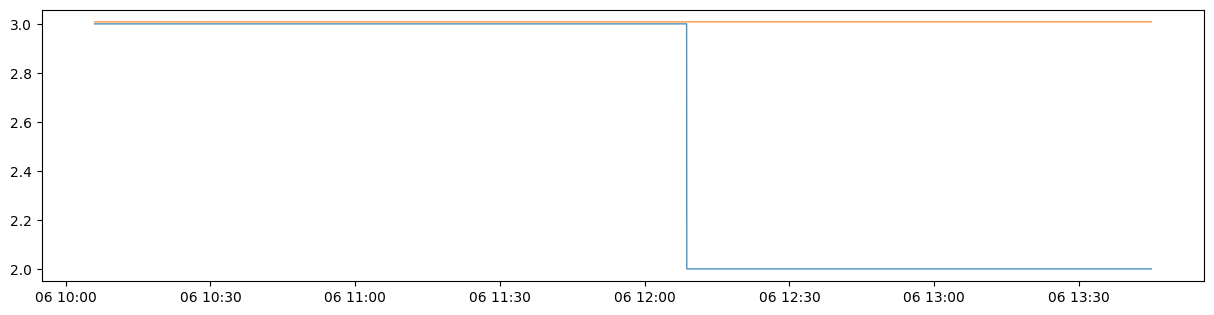

In [20]:
# --- Prediction for Entire Timeline (P1 Stage) ---

# 1. Load the best model
model.load_state_dict(torch.load("../models/lstm/AE_P1_best.pt"))
model.eval()

# 2. Prepare the full P1 dataset
# Ensure we use the same features as training (P1 stage)
X_all_P1 = np.load("../data/processed/step6/X_all_P1.npy")
full_dataset = WindowDataset(X_all_P1)
full_loader = DataLoader(full_dataset, batch_size=64, shuffle=False, drop_last=False)

# 3. Predict/Reconstruct
reconstructions = []
inputs = []

with torch.no_grad():
    for batch in full_loader:
        batch = batch.to(device)
        recon = model(batch)
        
        inputs.append(batch.cpu().numpy())
        reconstructions.append(recon.cpu().numpy())

# Concatenate batches
inputs = np.concatenate(inputs, axis=0)       # (N_windows, Window_Size, Features)
reconstructions = np.concatenate(reconstructions, axis=0)

print(f"Original shape: {inputs.shape}")
print(f"Reconstructed shape: {reconstructions.shape}")

# 4. Aggregation Strategy: Use the last point of each window for the timeline
# Matches typical 'forecasting' or 'reconstruction' at time t
actual_values = inputs[:, -1, :]
predicted_values = reconstructions[:, -1, :]

# Timestamps corresponding to the end of each window
# We saved these earlier
win_end_times = np.load("../data/processed/step5/window_end_times.npy", allow_pickle=True)
timestamps = pd.to_datetime(win_end_times)

# Verify shapes align
assert len(timestamps) == len(actual_values)
print(f"Timeline length: {len(timestamps)}")
print(f"Number of features: {actual_values.shape[1]}")




# --- Plot Actual vs Predicted for Selected Features ---
import matplotlib.pyplot as plt

# Load feature map to get names
with open("../data/processed/step6/stage_feature_map.json", "r") as f:
    stage_map = json.load(f)

p1_cols = stage_map.get('P1', [])

# Select a few features to plot (e.g., first 3 non-constant ones)
# We skip known constant indices if needed, or just plot.
features_to_plot = [0, 1, 2] # Adjust indices as needed

plt.figure(figsize=(15, 4 * len(features_to_plot)))

for i, feat_idx in enumerate(features_to_plot):
    if feat_idx >= len(p1_cols): break
    
    col_name = p1_cols[feat_idx]
    
    plt.subplot(len(features_to_plot), 1, i + 1)
    
    # Plot Actual
    plt.plot(timestamps, actual_values[:, feat_idx], label='Actual', color='#1f77b4', linewidth=1, alpha=0.8)
    # Plot Predicted
    plt.plot(timestamps, predicted_values[:, feat_idx], label='Reconstructed', color='#ff7f0e', linewidth=1, alpha=0.8)
    
    # Shade Attack Stages
    plt.axvspan(timestamps.min(), NORMAL_END, color='green', alpha=0.1, label='Normal' if i==0 else None)
    plt.axvspan(CYBER_ATTACK_START, CYBER_ATTACK_END, color='red', alpha=0.1, label='Cyber Attack' if i==0 else None)
    plt.axvspan(PHYSICAL_ATTACK_START, PHYSICAL_ATTACK_END, color='orange', alpha=0.1, label='Physical Attack' if i==0 else None)
    
    plt.title(f"Reconstruction: {col_name}")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

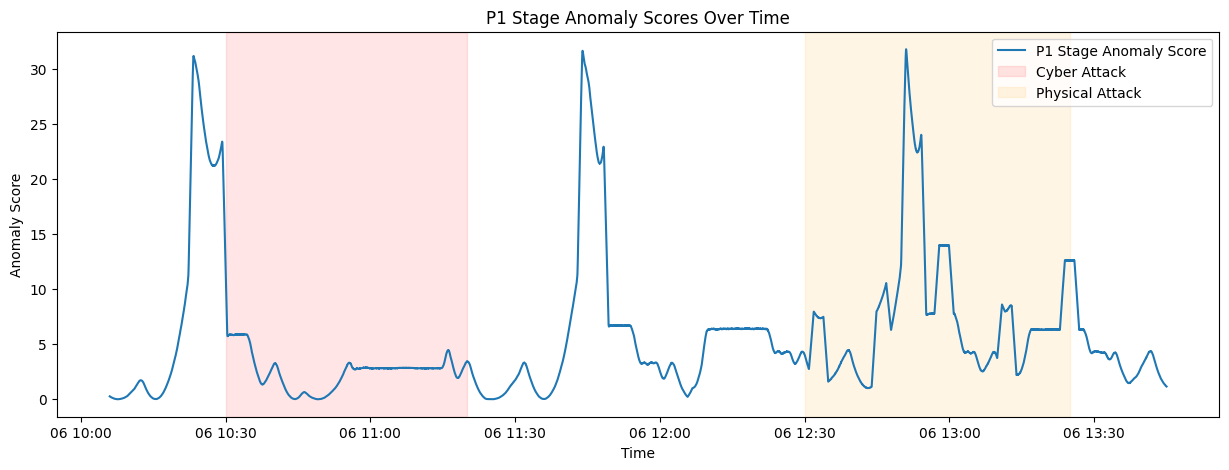

In [ ]:
import pandas as pd
df_scores_P1 = pd.DataFrame(
    feature_scores,
    index=pd.to_datetime(win_end),
    columns=[f"P1_feat_{i}" for i in range(feature_scores.shape[1])]
)

df_scores_P1["P1_stage_score"] = stage_scores

# plot
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.plot(df_scores_P1.index, df_scores_P1["P1_stage_score"], label="P1 Stage Anomaly Score", color='tab:blue')
plt.axvspan(pd.Timestamp("2019-12-06 10:30:00"), pd.Timestamp("2019-12-06 11:20:00"), color='red', alpha=0.1, label='Cyber Attack')
plt.axvspan(pd.Timestamp("2019-12-06 12:30:00"), pd.Timestamp("2019-12-06 13:25:00"), color='orange', alpha=0.1, label='Physical Attack')
plt.title("P1 Stage Anomaly Scores Over Time")
plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.legend()

df_scores_P1.to_csv("../data/processed/step7/swat_P1_anomaly_scores.csv")



